## Setup e Caricamento Dati

In [21]:
# Import librerie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

# Configurazione visualizzazioni
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Configurazione pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: f'{x:.2f}')

print("✓ Librerie caricate con successo")

✓ Librerie caricate con successo


In [22]:
# Carica dati dal CSV generato da sandra_report.py
OUTPUT_DIR = Path('../../output')
DATA_FILE = OUTPUT_DIR / 'sandra_midreport_data.csv'

if not DATA_FILE.exists():
    print("⚠ File dati non trovato!")
    print(f"Esegui prima: python ad_hoc_reports/sandra_report.py")
    print(f"File atteso: {DATA_FILE}")
else:
    df = pd.read_csv(DATA_FILE)
    
    # Converti date
    if 'publication_date' in df.columns:
        df['publication_date'] = pd.to_datetime(df['publication_date'])
    
    print(f"✓ Dati caricati: {len(df)} articoli")
    print(f"✓ Periodo: {df['publication_date'].min().date()} - {df['publication_date'].max().date()}")
    print(f"✓ Colonne disponibili: {len(df.columns)}")

✓ Dati caricati: 100 articoli
✓ Periodo: 2017-01-28 - 2025-12-30
✓ Colonne disponibili: 19


---
## 1. Comprensione della Struttura del Dato

In [23]:
print("📊 OVERVIEW DEL DATASET\n")
print(f"Numero totale di articoli: {len(df)}")
print(f"Periodo temporale: {(df['publication_date'].max() - df['publication_date'].min()).days} giorni")
print(f"\nColonne disponibili ({len(df.columns)}):")
for col in df.columns:
    print(f"  - {col}: {df[col].dtype}")

print("\n📈 Info dataset:")
df.info()

📊 OVERVIEW DEL DATASET

Numero totale di articoli: 100
Periodo temporale: 3258 giorni

Colonne disponibili (19):
  - editorial_rank: int64
  - editorial_score: float64
  - title: object
  - pagePath: object
  - publication_date: datetime64[ns]
  - author: object
  - category: object
  - content_segment: object
  - screenPageViews: int64
  - engagementRate: float64
  - averageSessionDuration: float64
  - feature_reach_rank: float64
  - feature_engagement_rank: float64
  - feature_depth_rank: float64
  - anomaly_flag: bool
  - feature_reach: float64
  - feature_engagement: float64
  - feature_depth: float64
  - segment_priority: int64

📈 Info dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 19 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   editorial_rank           100 non-null    int64         
 1   editorial_score          100 non-null    float64  

In [24]:
# Valori mancanti
print("\n🔍 VALORI MANCANTI\n")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Colonna': missing.index,
    'Valori Mancanti': missing.values,
    'Percentuale': missing_pct.values
})
missing_df = missing_df[missing_df['Valori Mancanti'] > 0].sort_values('Valori Mancanti', ascending=False)

if len(missing_df) > 0:
    print(missing_df.to_string(index=False))
else:
    print("✓ Nessun valore mancante rilevato")


🔍 VALORI MANCANTI

✓ Nessun valore mancante rilevato


In [25]:
# Statistiche descrittive per metriche chiave
print("\n📊 STATISTICHE DESCRITTIVE - METRICHE CHIAVE\n")
key_metrics = ['screenPageViews', 'engagementRate', 'averageSessionDuration', 
               'editorial_score', 'editorial_rank']
available_metrics = [col for col in key_metrics if col in df.columns]

if available_metrics:
    print(df[available_metrics].describe().round(2))


📊 STATISTICHE DESCRITTIVE - METRICHE CHIAVE

       screenPageViews  engagementRate  averageSessionDuration  \
count           100.00          100.00                  100.00   
mean             63.93            0.63                   88.34   
std              49.15            0.15                   37.12   
min              29.00            0.05                    7.87   
25%              34.00            0.54                   60.19   
50%              45.00            0.64                   86.17   
75%              72.75            0.75                  114.39   
max             338.00            0.95                  187.38   

       editorial_score  editorial_rank  
count           100.00          100.00  
mean             50.50           50.49  
std              17.67           29.01  
min              11.72            1.00  
25%              41.08           25.75  
50%              50.07           50.50  
75%              61.96           75.25  
max              92.60         

---
## 2. Analisi Temporale dei Contenuti

In [26]:
# Pubblicazioni per giorno della settimana
df['day_of_week'] = df['publication_date'].dt.day_name()
df['hour'] = df['publication_date'].dt.hour
df['date'] = df['publication_date'].dt.date

# Ordina giorni settimana
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_counts = df['day_of_week'].value_counts().reindex(day_order, fill_value=0)

print("\n📅 DISTRIBUZIONE PUBBLICAZIONI PER GIORNO DELLA SETTIMANA\n")
for day, count in day_counts.items():
    pct = (count / len(df) * 100)
    print(f"{day:12s}: {count:3d} articoli ({pct:5.1f}%)")


📅 DISTRIBUZIONE PUBBLICAZIONI PER GIORNO DELLA SETTIMANA

Monday      :  25 articoli ( 25.0%)
Tuesday     :  18 articoli ( 18.0%)
Wednesday   :  12 articoli ( 12.0%)
Thursday    :  14 articoli ( 14.0%)
Friday      :   8 articoli (  8.0%)
Saturday    :  14 articoli ( 14.0%)
Sunday      :   9 articoli (  9.0%)


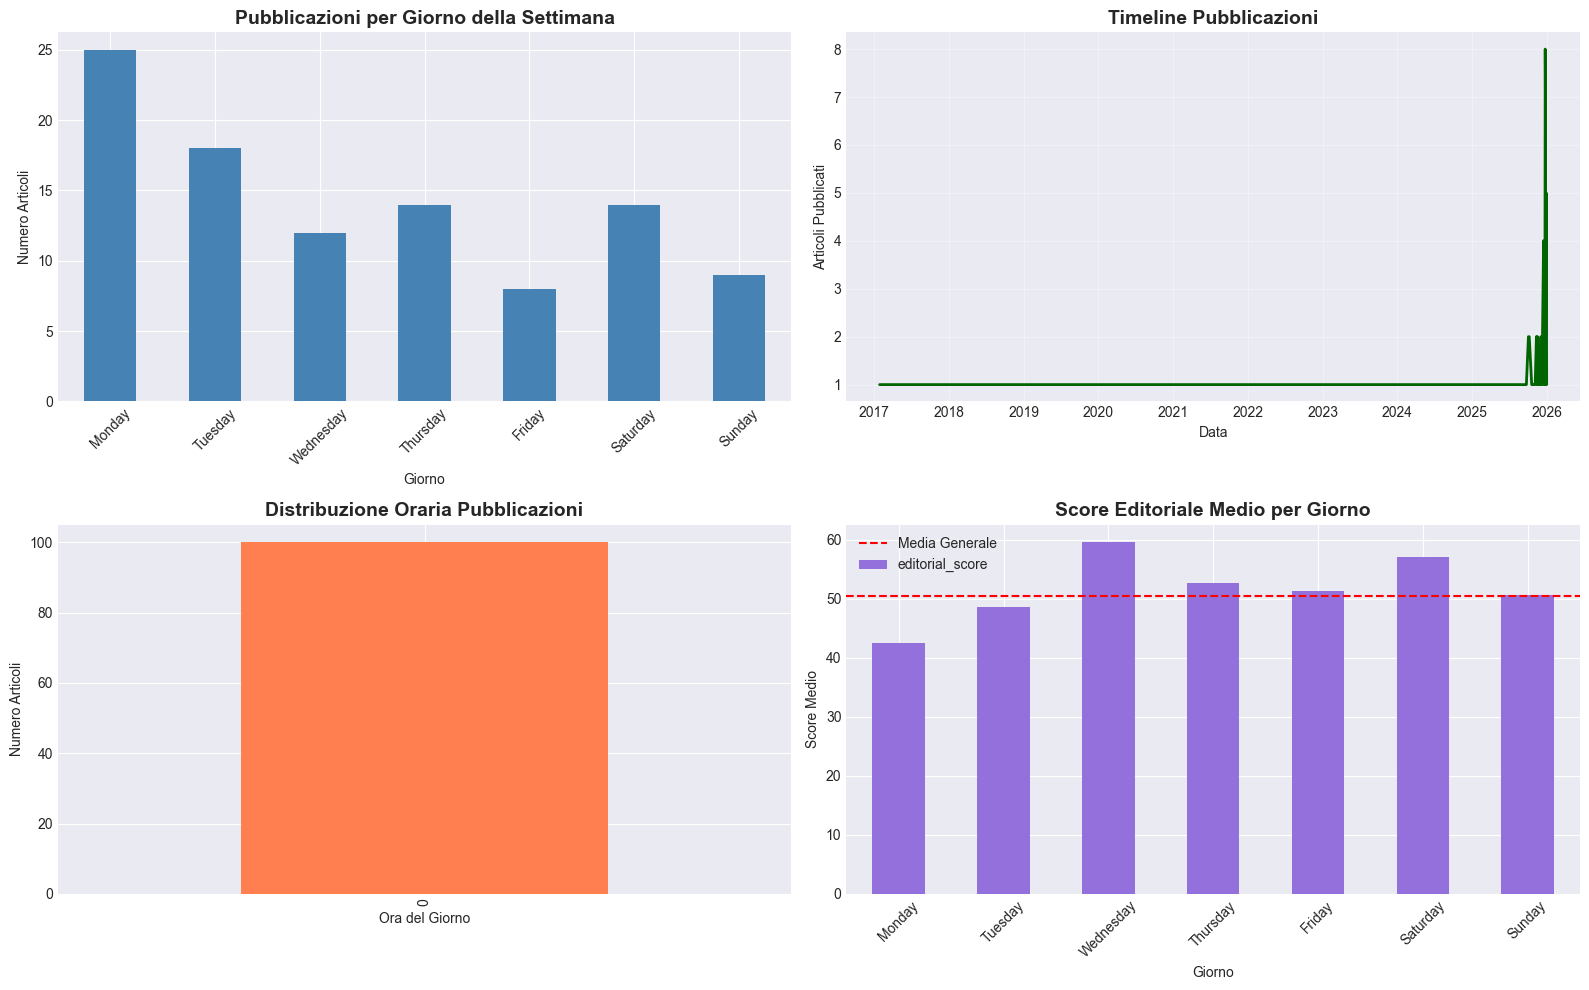


📈 Insight: Identifica i giorni/orari con maggiore attività e performance


In [27]:
# Visualizzazione distribuzione pubblicazioni
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Pubblicazioni per giorno settimana
ax1 = axes[0, 0]
day_counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Pubblicazioni per Giorno della Settimana', fontsize=14, fontweight='bold')
ax1.set_xlabel('Giorno')
ax1.set_ylabel('Numero Articoli')
ax1.tick_params(axis='x', rotation=45)

# 2. Timeline pubblicazioni
ax2 = axes[0, 1]
date_counts = df.groupby('date').size()
date_counts.plot(ax=ax2, color='darkgreen', linewidth=2)
ax2.set_title('Timeline Pubblicazioni', fontsize=14, fontweight='bold')
ax2.set_xlabel('Data')
ax2.set_ylabel('Articoli Pubblicati')
ax2.grid(True, alpha=0.3)

# 3. Distribuzione oraria
ax3 = axes[1, 0]
hour_counts = df['hour'].value_counts().sort_index()
hour_counts.plot(kind='bar', ax=ax3, color='coral')
ax3.set_title('Distribuzione Oraria Pubblicazioni', fontsize=14, fontweight='bold')
ax3.set_xlabel('Ora del Giorno')
ax3.set_ylabel('Numero Articoli')

# 4. Performance media per giorno settimana
ax4 = axes[1, 1]
if 'editorial_score' in df.columns:
    day_performance = df.groupby('day_of_week')['editorial_score'].mean().reindex(day_order)
    day_performance.plot(kind='bar', ax=ax4, color='mediumpurple')
    ax4.set_title('Score Editoriale Medio per Giorno', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Giorno')
    ax4.set_ylabel('Score Medio')
    ax4.tick_params(axis='x', rotation=45)
    ax4.axhline(y=df['editorial_score'].mean(), color='red', linestyle='--', label='Media Generale')
    ax4.legend()

plt.tight_layout()
plt.show()

print("\n📈 Insight: Identifica i giorni/orari con maggiore attività e performance")

---
## 3. Analisi delle Performance di Engagement

In [28]:
# Statistiche engagement per metriche chiave
print("\n🎯 PERFORMANCE DI ENGAGEMENT\n")

print("📊 Visualizzazioni (screenPageViews):")
views_stats = df['screenPageViews'].describe()
print(f"  Media: {views_stats['mean']:.0f}")
print(f"  Mediana: {views_stats['50%']:.0f}")
print(f"  Top 10%: {df['screenPageViews'].quantile(0.90):.0f}")
print(f"  Top 5%: {df['screenPageViews'].quantile(0.95):.0f}")
print(f"  Max: {views_stats['max']:.0f}")

print("\n📊 Engagement Rate:")
eng_stats = df['engagementRate'].describe()
print(f"  Media: {eng_stats['mean']:.2%}")
print(f"  Mediana: {eng_stats['50%']:.2%}")
print(f"  Top 10%: {df['engagementRate'].quantile(0.90):.2%}")
print(f"  Max: {eng_stats['max']:.2%}")

print("\n📊 Session Duration (secondi):")
dur_stats = df['averageSessionDuration'].describe()
print(f"  Media: {dur_stats['mean']:.0f}s ({dur_stats['mean']/60:.1f} min)")
print(f"  Mediana: {dur_stats['50%']:.0f}s ({dur_stats['50%']/60:.1f} min)")
print(f"  Top 10%: {df['averageSessionDuration'].quantile(0.90):.0f}s")
print(f"  Max: {dur_stats['max']:.0f}s ({dur_stats['max']/60:.1f} min)")


🎯 PERFORMANCE DI ENGAGEMENT

📊 Visualizzazioni (screenPageViews):
  Media: 64
  Mediana: 45
  Top 10%: 116
  Top 5%: 170
  Max: 338

📊 Engagement Rate:
  Media: 63.14%
  Mediana: 63.89%
  Top 10%: 80.68%
  Max: 95.00%

📊 Session Duration (secondi):
  Media: 88s (1.5 min)
  Mediana: 86s (1.4 min)
  Top 10%: 131s
  Max: 187s (3.1 min)


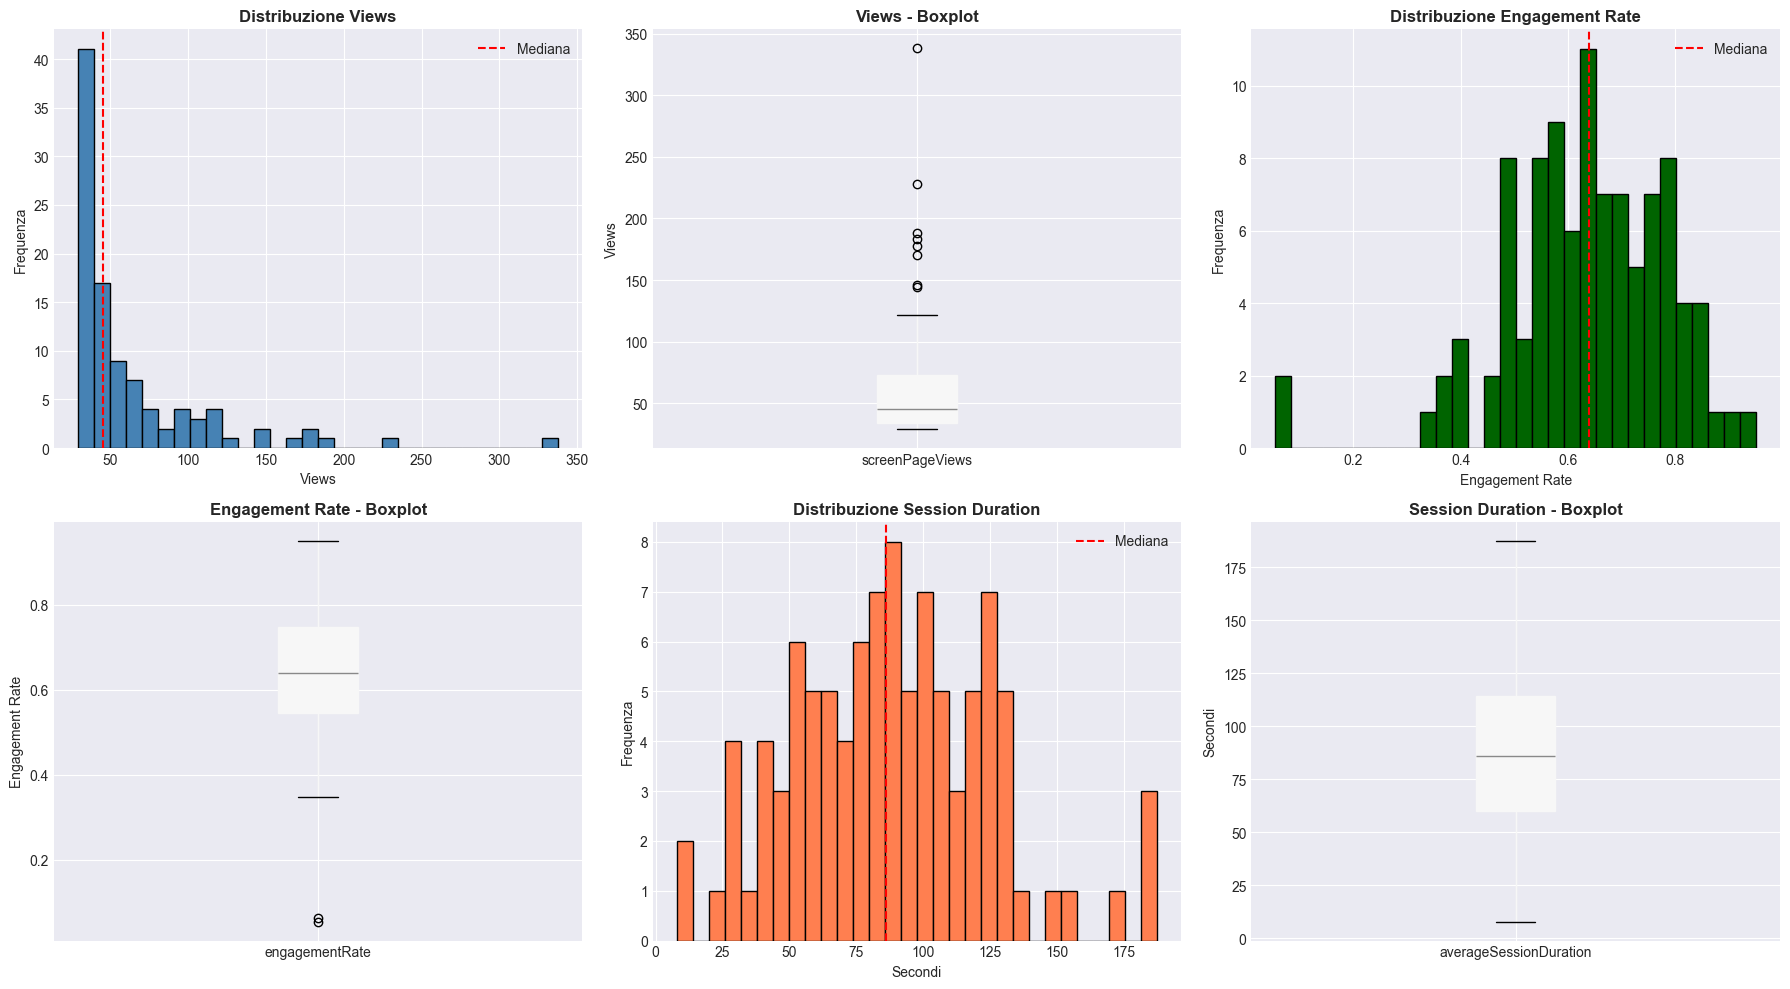

In [29]:
# Visualizzazione distribuzione metriche
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Views - Histogram
ax1 = axes[0, 0]
df['screenPageViews'].hist(bins=30, ax=ax1, color='steelblue', edgecolor='black')
ax1.set_title('Distribuzione Views', fontsize=12, fontweight='bold')
ax1.set_xlabel('Views')
ax1.set_ylabel('Frequenza')
ax1.axvline(df['screenPageViews'].median(), color='red', linestyle='--', label='Mediana')
ax1.legend()

# Views - Boxplot
ax2 = axes[0, 1]
df.boxplot(column='screenPageViews', ax=ax2, patch_artist=True)
ax2.set_title('Views - Boxplot', fontsize=12, fontweight='bold')
ax2.set_ylabel('Views')

# Engagement Rate - Histogram
ax3 = axes[0, 2]
df['engagementRate'].hist(bins=30, ax=ax3, color='darkgreen', edgecolor='black')
ax3.set_title('Distribuzione Engagement Rate', fontsize=12, fontweight='bold')
ax3.set_xlabel('Engagement Rate')
ax3.set_ylabel('Frequenza')
ax3.axvline(df['engagementRate'].median(), color='red', linestyle='--', label='Mediana')
ax3.legend()

# Engagement Rate - Boxplot
ax4 = axes[1, 0]
df.boxplot(column='engagementRate', ax=ax4, patch_artist=True)
ax4.set_title('Engagement Rate - Boxplot', fontsize=12, fontweight='bold')
ax4.set_ylabel('Engagement Rate')

# Session Duration - Histogram
ax5 = axes[1, 1]
df['averageSessionDuration'].hist(bins=30, ax=ax5, color='coral', edgecolor='black')
ax5.set_title('Distribuzione Session Duration', fontsize=12, fontweight='bold')
ax5.set_xlabel('Secondi')
ax5.set_ylabel('Frequenza')
ax5.axvline(df['averageSessionDuration'].median(), color='red', linestyle='--', label='Mediana')
ax5.legend()

# Session Duration - Boxplot
ax6 = axes[1, 2]
df.boxplot(column='averageSessionDuration', ax=ax6, patch_artist=True)
ax6.set_title('Session Duration - Boxplot', fontsize=12, fontweight='bold')
ax6.set_ylabel('Secondi')

plt.tight_layout()
plt.show()

In [30]:
# Top 10 articoli per ciascuna metrica
print("\n🏆 TOP 10 ARTICOLI - VIEWS\n")
top_views = df.nlargest(10, 'screenPageViews')[['title', 'screenPageViews', 'engagementRate', 'editorial_score']]
for idx, row in top_views.iterrows():
    print(f"{idx+1}. {row['title'][:60]}...")
    print(f"   Views: {row['screenPageViews']:.0f} | Engagement: {row['engagementRate']:.1%} | Score: {row['editorial_score']:.1f}\n")

print("\n🏆 TOP 10 ARTICOLI - ENGAGEMENT RATE\n")
top_engagement = df.nlargest(10, 'engagementRate')[['title', 'screenPageViews', 'engagementRate', 'editorial_score']]
for idx, row in top_engagement.iterrows():
    print(f"{idx+1}. {row['title'][:60]}...")
    print(f"   Views: {row['screenPageViews']:.0f} | Engagement: {row['engagementRate']:.1%} | Score: {row['editorial_score']:.1f}\n")


🏆 TOP 10 ARTICOLI - VIEWS

1. ‘Emily In Paris 6’: Netflix È Pronta A Continuare La Serie?...
   Views: 338 | Engagement: 56.4% | Score: 49.6

2. ‘Mayor Of Kingstown 5′: La Serie Crime Di Paramount+ Si Farà...
   Views: 228 | Engagement: 64.0% | Score: 61.5

3. ‘The Great’ 4: Il Destino Della Corte Russa...
   Views: 188 | Engagement: 55.5% | Score: 47.1

4. ‘Talamasca 2’: Cosa Riserva Il Futuro Della Serie...
   Views: 183 | Engagement: 62.9% | Score: 56.2

5. Gennaio 2026 Netflix: Cosa Guardare, Ecco Tutte Le Novità!...
   Views: 178 | Engagement: 78.8% | Score: 92.6

6. I Migliori Film Del 2025...
   Views: 170 | Engagement: 72.3% | Score: 72.8

7. ‘The Hunting Wives 2’ Arriva La Conferma Di Netflix...
   Views: 146 | Engagement: 58.0% | Score: 55.5

8. ‘Absentia 4’: Prime Video Chiude La Serie Al Terzo Capitolo...
   Views: 144 | Engagement: 53.4% | Score: 55.5

9. ‘Homeland 9’: Cala Il Sipario Sulla Serie...
   Views: 122 | Engagement: 56.5% | Score: 55.8

10. ‘Riv4Li’ 2 La Serie 

---
## 4. Analisi dei Feature Scores Normalizzati


🔗 CORRELAZIONE TRA FEATURE RANKS

                         feature_reach_rank  feature_engagement_rank  \
feature_reach_rank                     1.00                    -0.10   
feature_engagement_rank               -0.10                     1.00   
feature_depth_rank                    -0.08                     0.36   

                         feature_depth_rank  
feature_reach_rank                    -0.08  
feature_engagement_rank                0.36  
feature_depth_rank                     1.00  


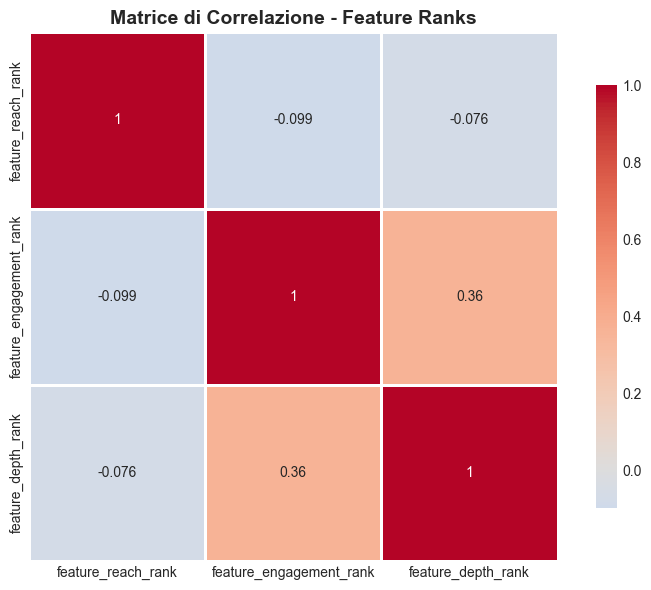


📊 Insight: Features fortemente correlate potrebbero indicare sovrapposizione


In [31]:
# Analisi correlazione tra feature ranks
feature_cols = ['feature_reach_rank', 'feature_engagement_rank', 'feature_depth_rank']
available_features = [col for col in feature_cols if col in df.columns]

if available_features:
    print("\n🔗 CORRELAZIONE TRA FEATURE RANKS\n")
    corr_matrix = df[available_features].corr()
    print(corr_matrix.round(3))
    
    # Heatmap correlazione
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
                square=True, linewidths=1, cbar_kws={"shrink": 0.8})
    plt.title('Matrice di Correlazione - Feature Ranks', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Insight: Features fortemente correlate potrebbero indicare sovrapposizione")

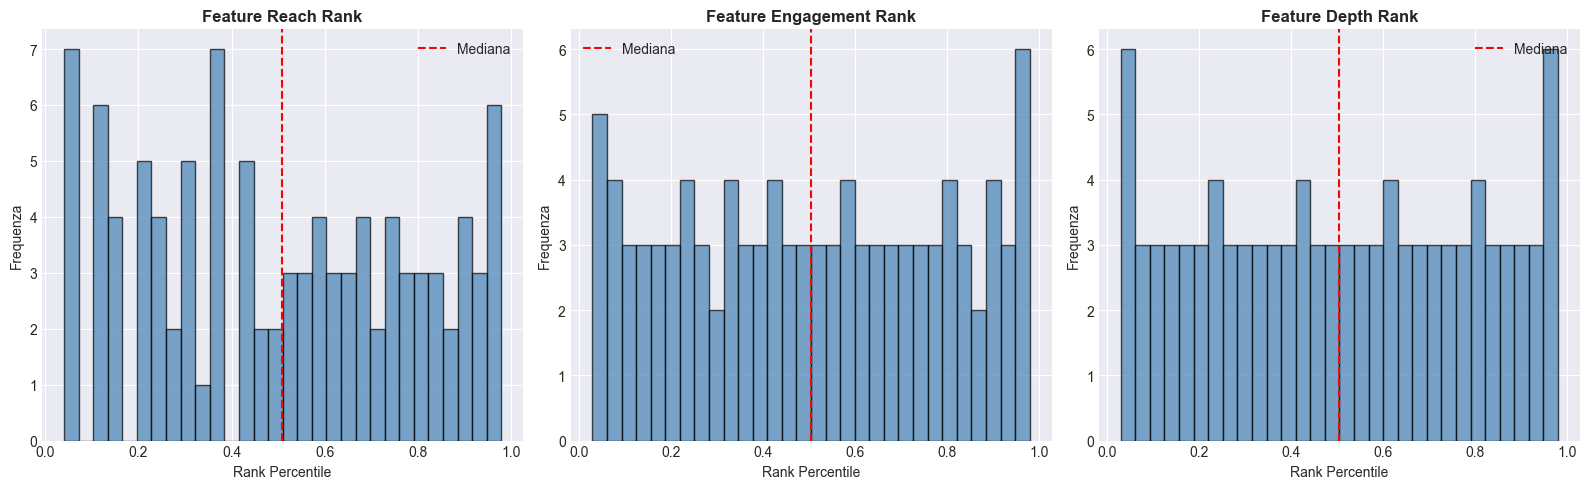


📊 Statistiche Feature Ranks:

       feature_reach_rank  feature_engagement_rank  feature_depth_rank
count              100.00                   100.00              100.00
mean                 0.51                     0.51                0.51
std                  0.29                     0.29                0.29
min                  0.04                     0.03                0.03
25%                  0.24                     0.26                0.26
50%                  0.51                     0.51                0.51
75%                  0.75                     0.75                0.75
max                  0.98                     0.98                0.98


In [32]:
# Distribuzione feature ranks
if available_features:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    for idx, feature in enumerate(available_features):
        ax = axes[idx]
        df[feature].hist(bins=30, ax=ax, color='steelblue', edgecolor='black', alpha=0.7)
        ax.set_title(f'{feature.replace("_", " ").title()}', fontsize=12, fontweight='bold')
        ax.set_xlabel('Rank Percentile')
        ax.set_ylabel('Frequenza')
        ax.axvline(df[feature].median(), color='red', linestyle='--', label='Mediana')
        ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Statistiche Feature Ranks:\n")
    print(df[available_features].describe().round(3))


🎯 CONTRIBUTO FEATURES AL SCORE EDITORIALE

Feature Reach Rank            : 0.480
Feature Engagement Rank       : 0.697
Feature Depth Rank            : 0.658


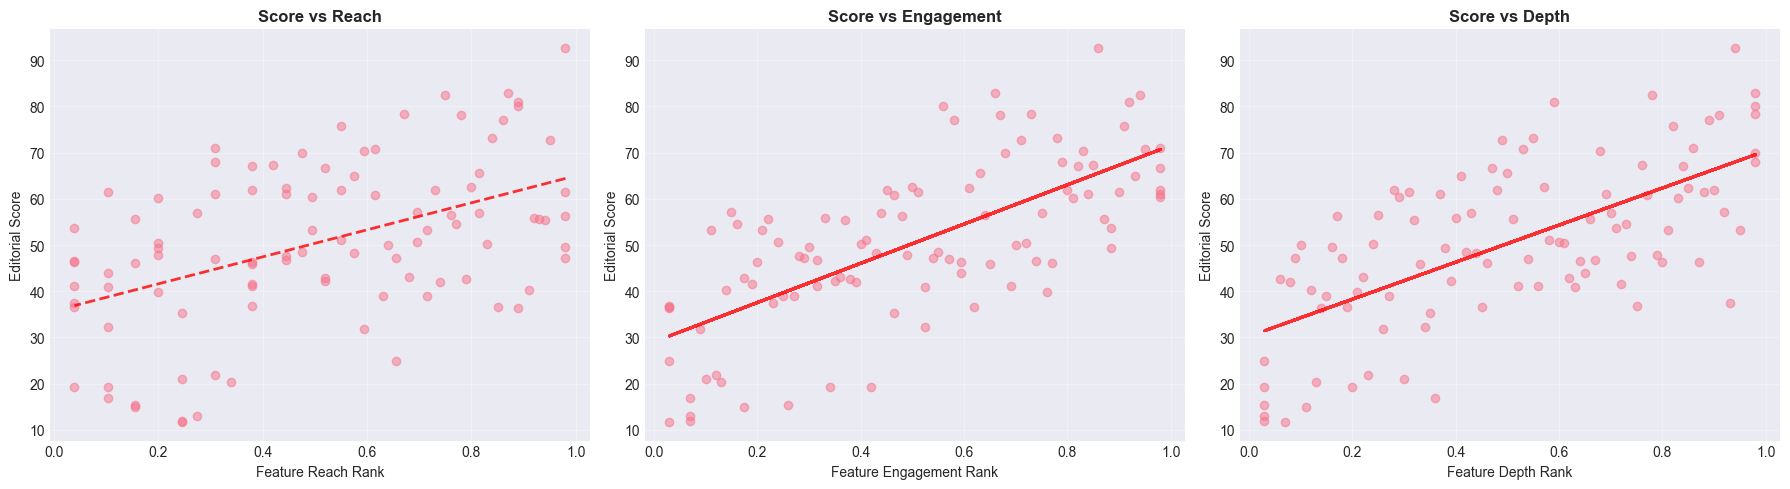

In [33]:
# Contributo delle feature al score finale
if 'editorial_score' in df.columns and available_features:
    print("\n🎯 CONTRIBUTO FEATURES AL SCORE EDITORIALE\n")
    
    for feature in available_features:
        corr = df[feature].corr(df['editorial_score'])
        print(f"{feature.replace('_', ' ').title():30s}: {corr:.3f}")
    
    # Scatter plots
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    for idx, feature in enumerate(available_features):
        ax = axes[idx]
        ax.scatter(df[feature], df['editorial_score'], alpha=0.5)
        ax.set_xlabel(feature.replace('_', ' ').title())
        ax.set_ylabel('Editorial Score')
        ax.set_title(f'Score vs {feature.replace("feature_", "").replace("_rank", "").title()}', 
                     fontsize=12, fontweight='bold')
        
        # Linea di tendenza
        z = np.polyfit(df[feature], df['editorial_score'], 1)
        p = np.poly1d(z)
        ax.plot(df[feature], p(df[feature]), "r--", alpha=0.8, linewidth=2)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

---
## 5. Analisi per Segmenti Editoriali


📋 DISTRIBUZIONE SEGMENTI EDITORIALI

Standard            :  54 articoli ( 54.0%)
Niche Value         :  32 articoli ( 32.0%)
Rising Star         :   7 articoli (  7.0%)
Top Performer       :   5 articoli (  5.0%)
Underperforming     :   2 articoli (  2.0%)


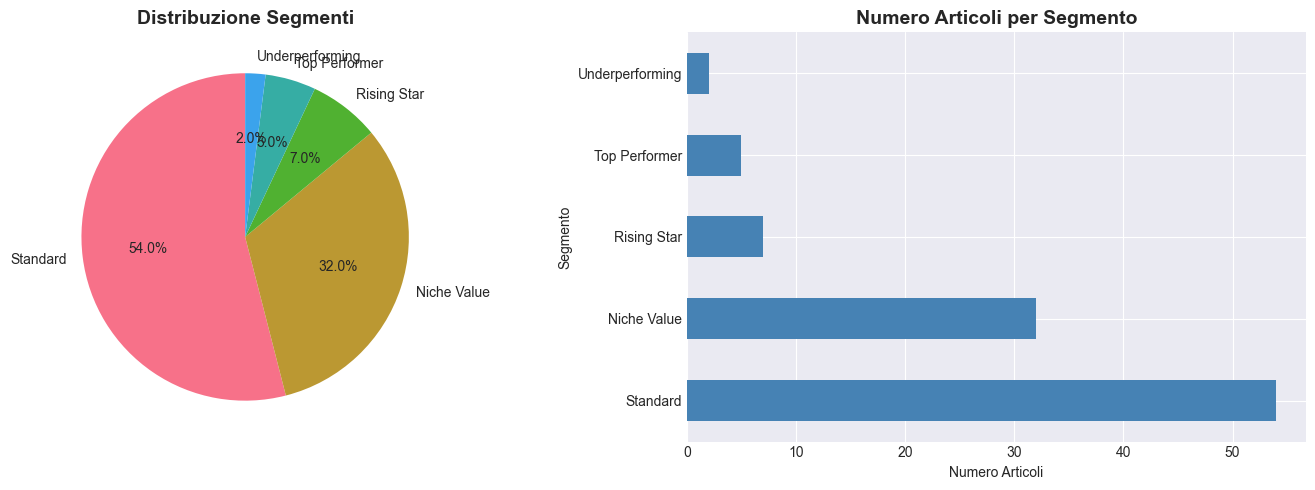

In [34]:
# Distribuzione segmenti
if 'content_segment' in df.columns:
    print("\n📋 DISTRIBUZIONE SEGMENTI EDITORIALI\n")
    segment_dist = df['content_segment'].value_counts()
    segment_pct = (segment_dist / len(df) * 100).round(1)
    
    for segment, count in segment_dist.items():
        pct = segment_pct[segment]
        print(f"{segment:20s}: {count:3d} articoli ({pct:5.1f}%)")
    
    # Visualizzazione
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Pie chart
    ax1 = axes[0]
    segment_dist.plot(kind='pie', ax=ax1, autopct='%1.1f%%', startangle=90)
    ax1.set_title('Distribuzione Segmenti', fontsize=14, fontweight='bold')
    ax1.set_ylabel('')
    
    # Bar chart
    ax2 = axes[1]
    segment_dist.plot(kind='barh', ax=ax2, color='steelblue')
    ax2.set_title('Numero Articoli per Segmento', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Numero Articoli')
    ax2.set_ylabel('Segmento')
    
    plt.tight_layout()
    plt.show()


📊 PERFORMANCE PER SEGMENTO

                screenPageViews              engagementRate         \
                           mean median   sum           mean median   
content_segment                                                      
Niche Value               47.31  39.00  1514           0.78   0.77   
Rising Star               93.86  89.00   657           0.65   0.64   
Standard                  65.61  45.00  3543           0.55   0.56   
Top Performer            118.00 115.00   590           0.76   0.79   
Underperforming           44.50  44.50    89           0.06   0.06   

                averageSessionDuration        editorial_score               \
                                  mean median            mean median   min   
content_segment                                                              
Niche Value                     101.50  98.11           61.17  61.76 39.90   
Rising Star                     107.28 116.40           64.58  62.42 60.90   
Standard            

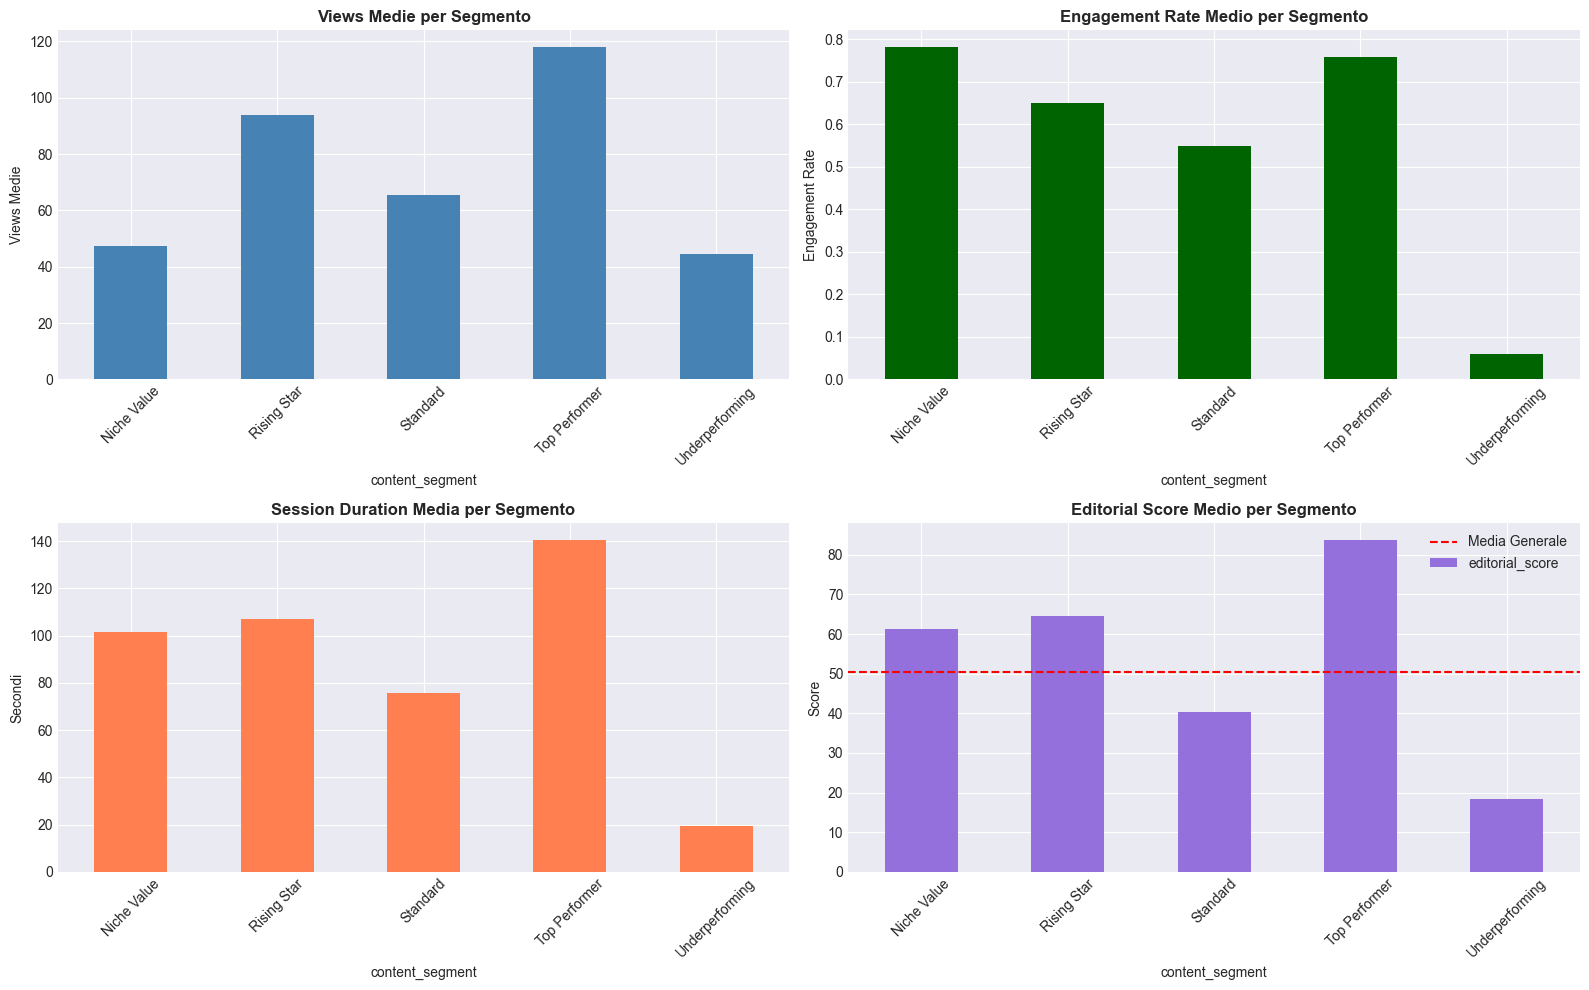

In [35]:
# Performance per segmento
if 'content_segment' in df.columns:
    print("\n📊 PERFORMANCE PER SEGMENTO\n")
    
    segment_stats = df.groupby('content_segment').agg({
        'screenPageViews': ['mean', 'median', 'sum'],
        'engagementRate': ['mean', 'median'],
        'averageSessionDuration': ['mean', 'median'],
        'editorial_score': ['mean', 'median', 'min', 'max']
    }).round(2)
    
    print(segment_stats)
    
    # Visualizzazione comparativa
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    # Views medie per segmento
    ax1 = axes[0, 0]
    df.groupby('content_segment')['screenPageViews'].mean().plot(kind='bar', ax=ax1, color='steelblue')
    ax1.set_title('Views Medie per Segmento', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Views Medie')
    ax1.tick_params(axis='x', rotation=45)
    
    # Engagement rate medio per segmento
    ax2 = axes[0, 1]
    df.groupby('content_segment')['engagementRate'].mean().plot(kind='bar', ax=ax2, color='darkgreen')
    ax2.set_title('Engagement Rate Medio per Segmento', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Engagement Rate')
    ax2.tick_params(axis='x', rotation=45)
    
    # Session duration media per segmento
    ax3 = axes[1, 0]
    df.groupby('content_segment')['averageSessionDuration'].mean().plot(kind='bar', ax=ax3, color='coral')
    ax3.set_title('Session Duration Media per Segmento', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Secondi')
    ax3.tick_params(axis='x', rotation=45)
    
    # Editorial score medio per segmento
    ax4 = axes[1, 1]
    df.groupby('content_segment')['editorial_score'].mean().plot(kind='bar', ax=ax4, color='mediumpurple')
    ax4.set_title('Editorial Score Medio per Segmento', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Score')
    ax4.tick_params(axis='x', rotation=45)
    ax4.axhline(y=df['editorial_score'].mean(), color='red', linestyle='--', label='Media Generale')
    ax4.legend()
    
    plt.tight_layout()
    plt.show()

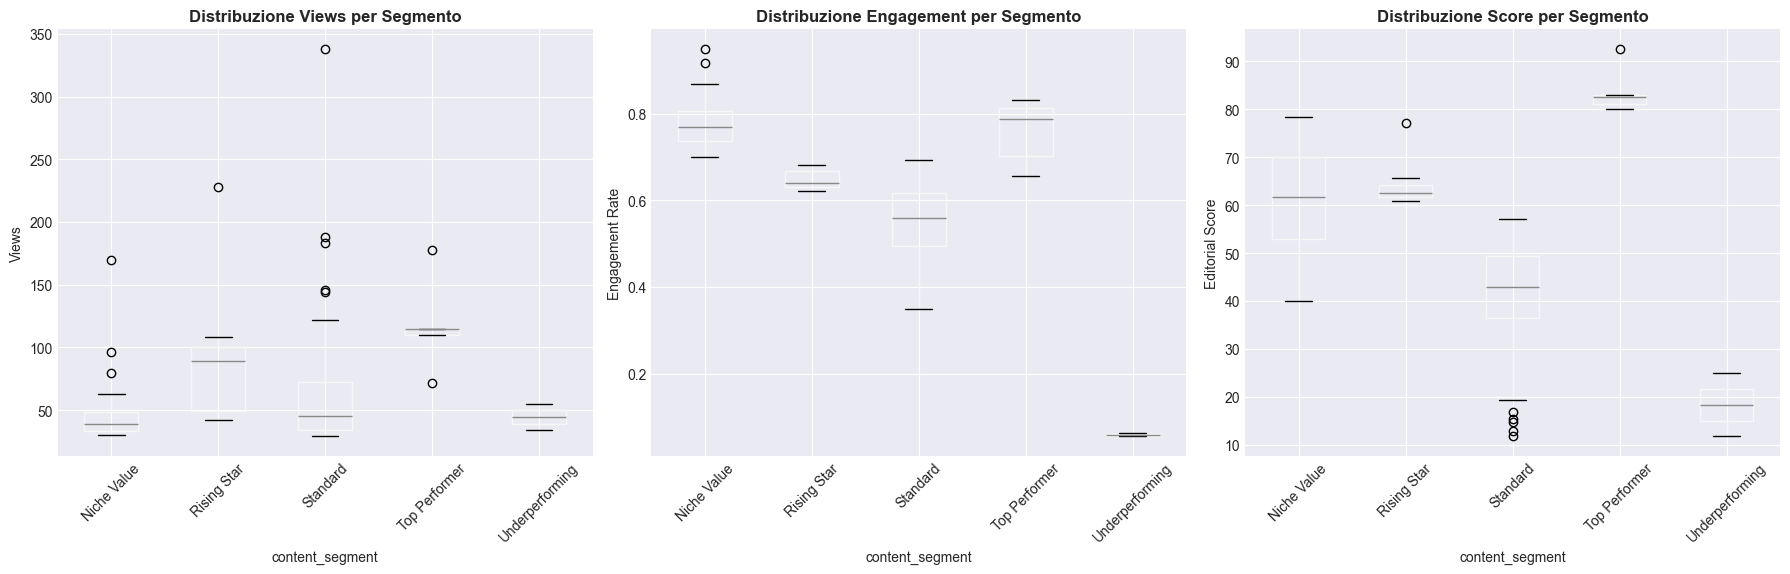


📊 Insight: Valuta la coerenza interna dei segmenti e identifica outliers


In [36]:
# Boxplot comparativi per segmento
if 'content_segment' in df.columns:
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Views
    ax1 = axes[0]
    df.boxplot(column='screenPageViews', by='content_segment', ax=ax1)
    ax1.set_title('Distribuzione Views per Segmento', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Views')
    ax1.tick_params(axis='x', rotation=45)
    
    # Engagement Rate
    ax2 = axes[1]
    df.boxplot(column='engagementRate', by='content_segment', ax=ax2)
    ax2.set_title('Distribuzione Engagement per Segmento', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Engagement Rate')
    ax2.tick_params(axis='x', rotation=45)
    
    # Editorial Score
    ax3 = axes[2]
    df.boxplot(column='editorial_score', by='content_segment', ax=ax3)
    ax3.set_title('Distribuzione Score per Segmento', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Editorial Score')
    ax3.tick_params(axis='x', rotation=45)
    
    plt.suptitle('')  # Rimuove titolo automatico
    plt.tight_layout()
    plt.show()
    
    print("\n📊 Insight: Valuta la coerenza interna dei segmenti e identifica outliers")

---
## 6. Analisi delle Anomalie

In [44]:
# Articoli con flag anomalia
if 'anomaly_flag' in df.columns:
    anomalies = df[df['anomaly_flag'] == True]
    
    print(f"\n⚠ ANALISI ANOMALIE\n")
    print(f"Totale articoli con anomalie: {len(anomalies)} ({len(anomalies)/len(df)*100:.1f}%)\n")
    
    if len(anomalies) > 0:
        print("Caratteristiche degli articoli anomali:\n")
        print(anomalies[['title', 'editorial_score', 'screenPageViews', 'engagementRate', 'content_segment']].to_string(index=False))
        
        # Distribuzione anomalie per segmento
        if 'content_segment' in df.columns:
            print("\n📊 Distribuzione anomalie per segmento:\n")
            anomaly_by_segment = anomalies['content_segment'].value_counts()
            for segment, count in anomaly_by_segment.items():
                total_in_segment = len(df[df['content_segment'] == segment])
                pct = (count / total_in_segment * 100)
                print(f"{segment:20s}: {count:2d} anomalie ({pct:5.1f}% del segmento)")
    else:
        print("✓ Nessuna anomalia rilevata")
else:
    print("\n⚠ Colonna anomaly_flag non disponibile")


⚠ ANALISI ANOMALIE

Totale articoli con anomalie: 0 (0.0%)

✓ Nessuna anomalia rilevata


In [38]:
# Identificazione opportunità: alto score ma basse views
print("\n🎯 OPPORTUNITÀ: Alto Score Editoriale, Basse Views\n")
print("Articoli di qualità che potrebbero beneficiare di maggiore promozione:\n")

high_score_low_views = df[
    (df['editorial_score'] > df['editorial_score'].quantile(0.75)) &
    (df['screenPageViews'] < df['screenPageViews'].quantile(0.25))
].sort_values('editorial_score', ascending=False)

if len(high_score_low_views) > 0:
    for idx, row in high_score_low_views.head(10).iterrows():
        print(f"• {row['title'][:70]}")
        print(f"  Score: {row['editorial_score']:.1f} | Views: {row['screenPageViews']:.0f} | Engagement: {row['engagementRate']:.1%}\n")
else:
    print("Nessun articolo identificato in questa categoria")


🎯 OPPORTUNITÀ: Alto Score Editoriale, Basse Views

Articoli di qualità che potrebbero beneficiare di maggiore promozione:

Nessun articolo identificato in questa categoria


In [39]:
# Identificazione criticità: alte views ma basso engagement
print("\n⚠ CRITICITÀ: Alte Views, Basso Engagement\n")
print("Articoli che attirano traffico ma non coinvolgono (da ottimizzare):\n")

high_views_low_engagement = df[
    (df['screenPageViews'] > df['screenPageViews'].quantile(0.75)) &
    (df['engagementRate'] < df['engagementRate'].quantile(0.25))
].sort_values('screenPageViews', ascending=False)

if len(high_views_low_engagement) > 0:
    for idx, row in high_views_low_engagement.head(10).iterrows():
        print(f"• {row['title'][:70]}")
        print(f"  Views: {row['screenPageViews']:.0f} | Engagement: {row['engagementRate']:.1%} | Score: {row['editorial_score']:.1f}\n")
else:
    print("Nessun articolo identificato in questa categoria")


⚠ CRITICITÀ: Alte Views, Basso Engagement

Articoli che attirano traffico ma non coinvolgono (da ottimizzare):

• ‘Absentia 4’: Prime Video Chiude La Serie Al Terzo Capitolo
  Views: 144 | Engagement: 53.4% | Score: 55.5

• ‘Riv4Li’ 2 La Serie Ci Sarà?
  Views: 121 | Engagement: 49.1% | Score: 40.4

• ‘Merv’: A Natale L’Amore Torna A Scodinzolare
  Views: 115 | Engagement: 34.9% | Score: 36.4

• Anime Da Guardare Assolutamente: Ecco 10 Serie Adatte A Tutti
  Views: 104 | Engagement: 35.7% | Score: 36.5

• ‘The One’: La Storia Vera Dell’Unica Superstite Dell’Aeroflot Flight 8
  Views: 76 | Engagement: 49.3% | Score: 54.5



---
## 7. Analisi per Autore e Categoria


👤 PERFORMANCE PER AUTORE

                        Articoli  Views Totali  Views Medie  Engagement Medio  \
author                                                                          
Margherita Fratantonio         1            58        58.00              0.73   
Edoardo Barci                  1           108       108.00              0.66   
Eleonora Ceccarelli            1            47        47.00              0.81   
Giacomo Mosca                  1            37        37.00              0.92   
Sabrina Colangeli              1            51        51.00              0.84   
Antonio Quaranta               1            43        43.00              0.71   
Mattia Pastore                 1            39        39.00              0.77   
Pamela Alosilla                3           471       157.00              0.68   
Redazione                      5           465        93.00              0.68   
Francesco Sarasso              1            47        47.00              0.62   



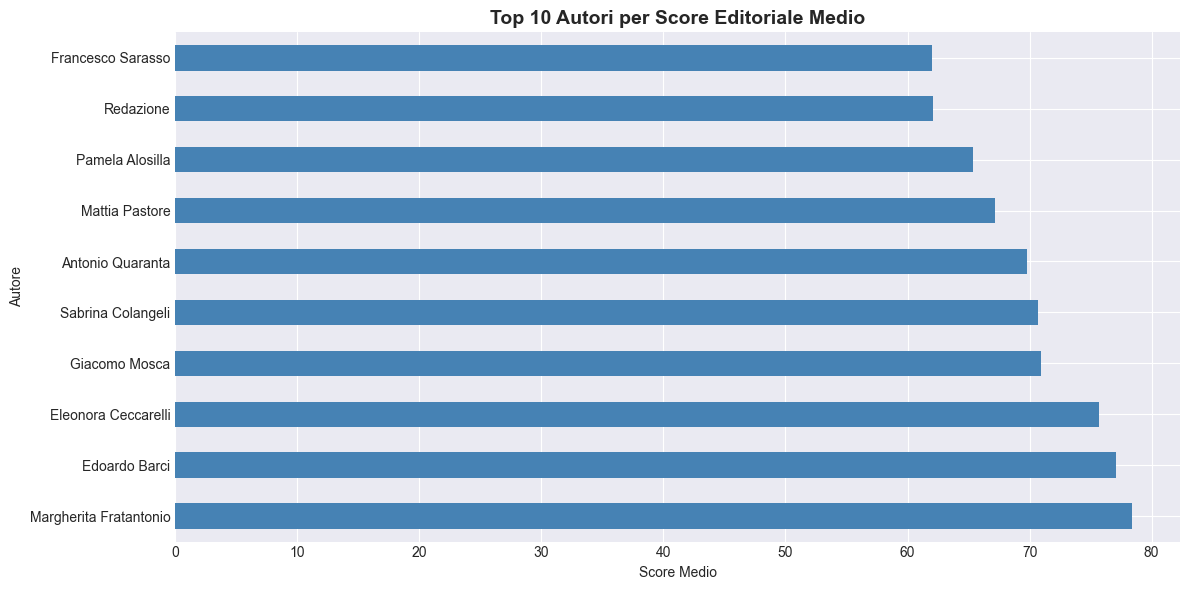

In [40]:
# Performance per autore
if 'author' in df.columns:
    print("\n👤 PERFORMANCE PER AUTORE\n")
    
    author_stats = df.groupby('author').agg({
        'title': 'count',
        'screenPageViews': ['sum', 'mean'],
        'engagementRate': 'mean',
        'editorial_score': 'mean'
    }).round(2)
    
    author_stats.columns = ['Articoli', 'Views Totali', 'Views Medie', 'Engagement Medio', 'Score Medio']
    author_stats = author_stats.sort_values('Score Medio', ascending=False)
    
    print(author_stats.head(10))
    
    # Top 10 autori per score medio
    top_authors = author_stats.head(10)['Score Medio']
    
    plt.figure(figsize=(12, 6))
    top_authors.plot(kind='barh', color='steelblue')
    plt.title('Top 10 Autori per Score Editoriale Medio', fontsize=14, fontweight='bold')
    plt.xlabel('Score Medio')
    plt.ylabel('Autore')
    plt.tight_layout()
    plt.show()


📂 PERFORMANCE PER CATEGORIA

                          Articoli  Views Totali  Views Medie  \
category                                                        
Recensioni / In Sala             3           213        71.00   
Cult Movies                      1            39        39.00   
Live Streaming On Demand        16           915        57.19   
Serie TV                         8           388        48.50   
Anticipazioni                    6           262        43.67   
News                            14           718        51.29   
Trailers                         2            75        37.50   
Speciali e Magazine             16          1001        62.56   
Recensioni                       6           316        52.67   
Interviste                       2            76        38.00   
Si farà                         23          2175        94.57   
Animazione                       1           104       104.00   
Altro                            2           111        55.5

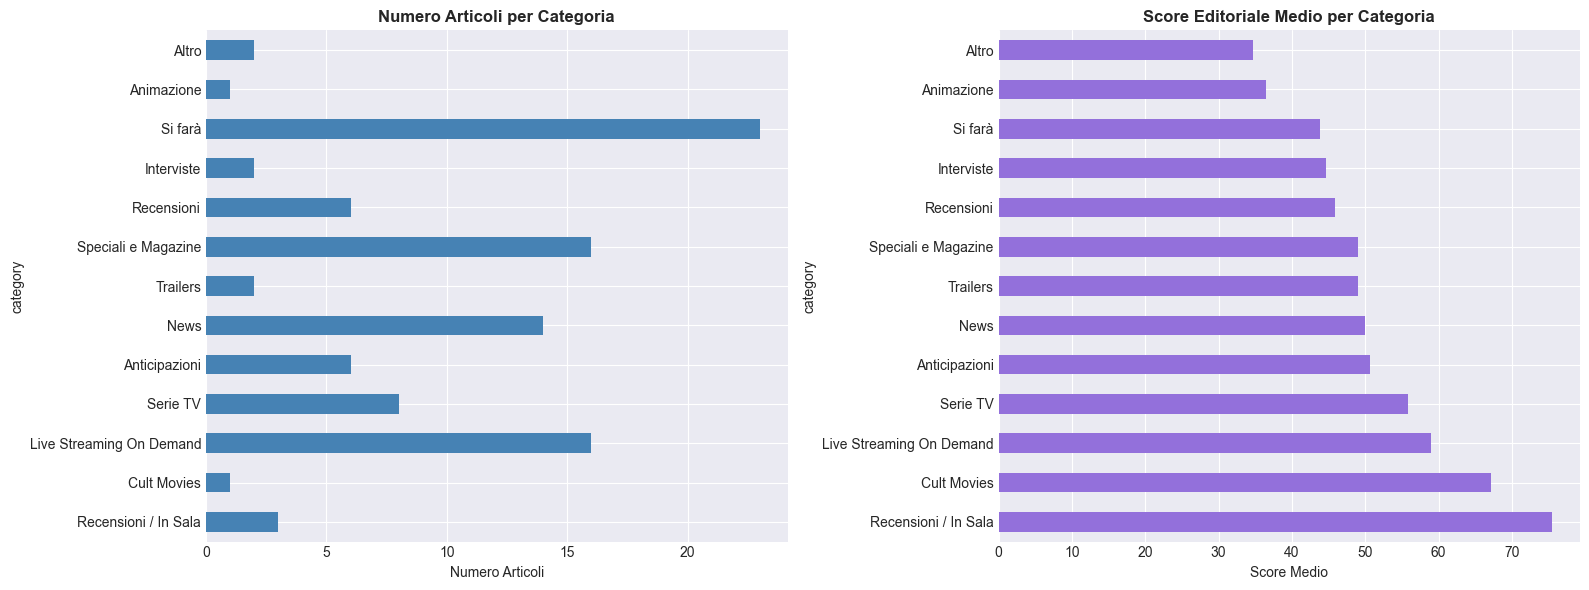

In [41]:
# Performance per categoria
if 'category' in df.columns:
    print("\n📂 PERFORMANCE PER CATEGORIA\n")
    
    category_stats = df.groupby('category').agg({
        'title': 'count',
        'screenPageViews': ['sum', 'mean'],
        'engagementRate': 'mean',
        'editorial_score': 'mean'
    }).round(2)
    
    category_stats.columns = ['Articoli', 'Views Totali', 'Views Medie', 'Engagement Medio', 'Score Medio']
    category_stats = category_stats.sort_values('Score Medio', ascending=False)
    
    print(category_stats)
    
    # Visualizzazione
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Numero articoli per categoria
    ax1 = axes[0]
    category_stats['Articoli'].plot(kind='barh', ax=ax1, color='steelblue')
    ax1.set_title('Numero Articoli per Categoria', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Numero Articoli')
    
    # Score medio per categoria
    ax2 = axes[1]
    category_stats['Score Medio'].plot(kind='barh', ax=ax2, color='mediumpurple')
    ax2.set_title('Score Editoriale Medio per Categoria', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Score Medio')
    
    plt.tight_layout()
    plt.show()

---
## 8. Raccomandazioni Strategiche

In [42]:
print("\n" + "="*80)
print("📋 RACCOMANDAZIONI STRATEGICHE PER IL TEAM EDITORIALE")
print("="*80 + "\n")

# 1. Migliori giorni per pubblicare
if 'day_of_week' in df.columns and 'editorial_score' in df.columns:
    best_days = df.groupby('day_of_week')['editorial_score'].mean().sort_values(ascending=False)
    print("1. 📅 TIMING OTTIMALE DI PUBBLICAZIONE")
    print(f"   Migliori giorni: {', '.join(best_days.head(3).index.tolist())}")
    print(f"   Score medio nei giorni migliori: {best_days.head(3).mean():.1f}\n")

# 2. Segmenti con migliori performance
if 'content_segment' in df.columns:
    best_segments = df.groupby('content_segment')['editorial_score'].mean().sort_values(ascending=False)
    print("2. 🎯 SEGMENTI AD ALTA PERFORMANCE")
    for segment in best_segments.head(3).index:
        score = best_segments[segment]
        count = len(df[df['content_segment'] == segment])
        print(f"   • {segment}: Score {score:.1f} ({count} articoli)")
    print()

# 3. Feature più impattanti
if available_features and 'editorial_score' in df.columns:
    print("3. 🔑 DRIVER CHIAVE DI SUCCESSO")
    correlations = {}
    for feature in available_features:
        correlations[feature] = df[feature].corr(df['editorial_score'])
    
    sorted_corr = sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
    for feature, corr in sorted_corr:
        feature_name = feature.replace('feature_', '').replace('_rank', '').title()
        print(f"   • {feature_name}: Correlazione {corr:.3f}")
    print()

# 4. Opportunità di miglioramento
print("4. 💡 OPPORTUNITÀ IMMEDIATE")
print(f"   • {len(high_score_low_views)} articoli di qualità da promuovere")
print(f"   • {len(high_views_low_engagement)} articoli da ottimizzare per engagement")
if 'anomaly_flag' in df.columns:
    print(f"   • {len(df[df['anomaly_flag']==True])} articoli anomali da rivedere")
print()

# 5. Metriche chiave da monitorare
print("5. 📊 METRICHE DA MONITORARE COSTANTEMENTE")
print(f"   • Engagement Rate Target: >{df['engagementRate'].quantile(0.75):.1%}")
print(f"   • Views Obiettivo: >{df['screenPageViews'].quantile(0.75):.0f}")
print(f"   • Session Duration Target: >{df['averageSessionDuration'].quantile(0.75):.0f}s")
print(f"   • Editorial Score Target: >{df['editorial_score'].quantile(0.75):.1f}")

print("\n" + "="*80)
print("✓ Analisi completata")
print("="*80)


📋 RACCOMANDAZIONI STRATEGICHE PER IL TEAM EDITORIALE

1. 📅 TIMING OTTIMALE DI PUBBLICAZIONE
   Migliori giorni: Wednesday, Saturday, Thursday
   Score medio nei giorni migliori: 56.4

2. 🎯 SEGMENTI AD ALTA PERFORMANCE
   • Top Performer: Score 83.9 (5 articoli)
   • Rising Star: Score 64.6 (7 articoli)
   • Niche Value: Score 61.2 (32 articoli)

3. 🔑 DRIVER CHIAVE DI SUCCESSO
   • Engagement: Correlazione 0.697
   • Depth: Correlazione 0.658
   • Reach: Correlazione 0.480

4. 💡 OPPORTUNITÀ IMMEDIATE
   • 0 articoli di qualità da promuovere
   • 5 articoli da ottimizzare per engagement
   • 0 articoli anomali da rivedere

5. 📊 METRICHE DA MONITORARE COSTANTEMENTE
   • Engagement Rate Target: >74.7%
   • Views Obiettivo: >73
   • Session Duration Target: >114s
   • Editorial Score Target: >62.0

✓ Analisi completata


---
## Export dei Report

Salva i risultati chiave per condivisione con il team.

In [43]:
# Export top performers
top_performers = df.nlargest(20, 'editorial_score')[[
    'editorial_rank', 'editorial_score', 'title', 'author', 'category',
    'screenPageViews', 'engagementRate', 'averageSessionDuration', 'content_segment'
]]

export_file = OUTPUT_DIR / 'sandra_eda_top_performers.xlsx'
top_performers.to_excel(export_file, index=False)
print(f"\n✓ Top performers esportati in: {export_file}")

# Export opportunità (alto score, basse views)
if len(high_score_low_views) > 0:
    opportunities_file = OUTPUT_DIR / 'sandra_eda_opportunities.xlsx'
    high_score_low_views[[
        'title', 'editorial_score', 'screenPageViews', 'engagementRate', 'category', 'author'
    ]].to_excel(opportunities_file, index=False)
    print(f"✓ Opportunità esportate in: {opportunities_file}")

# Export criticità (alte views, basso engagement)
if len(high_views_low_engagement) > 0:
    issues_file = OUTPUT_DIR / 'sandra_eda_issues.xlsx'
    high_views_low_engagement[[
        'title', 'screenPageViews', 'engagementRate', 'editorial_score', 'category', 'author'
    ]].to_excel(issues_file, index=False)
    print(f"✓ Criticità esportate in: {issues_file}")

print("\n✅ Export completati!")


✓ Top performers esportati in: ..\..\output\sandra_eda_top_performers.xlsx
✓ Criticità esportate in: ..\..\output\sandra_eda_issues.xlsx

✅ Export completati!
